In [2]:
import pandas as pd
import datetime as dt
from matplotlib import pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
def replace_timestamps_with_step_times(df):
    step_names = ["prefetch", "fasterq_dump", "salmon", "deseq2"]
    for step_name in step_names:
        start_times = (pd.to_datetime(df[f"{step_name}_start_time"]) - dt.datetime(1970,1,1)).dt.total_seconds()
        end_times = (pd.to_datetime(df[f"{step_name}_end_time"]) - dt.datetime(1970,1,1)).dt.total_seconds()
        df[f"{step_name} [s]"] = end_times - start_times

    return df

In [4]:
df_prices = pd.DataFrame(data={"price_per_h": [0.3060, 0.3400, 0.3570, 0.4106]}, index=["c6a_2xlarge", "c6i_2xlarge", "c7i_2xlarge", "c7a_2xlarge"])

In [5]:
df_c6a = replace_timestamps_with_step_times(pd.read_csv("data/c6a_2xlarge.csv"))
df_c6i = replace_timestamps_with_step_times(pd.read_csv("data/c6i_2xlarge.csv"))
df_c7a = replace_timestamps_with_step_times(pd.read_csv("data/c7a_2xlarge.csv"))
df_c7i = replace_timestamps_with_step_times(pd.read_csv("data/c7i_2xlarge.csv"))

In [6]:
print(f"c6a.2xlarge mean Salmon execution time: {(df_c6a['salmon [s]'].sum() / 3600):.2f} h")
print(f"c6i.2xlarge mean Salmon execution time: {(df_c6i['salmon [s]'].sum() / 3600):.2f} h")
print(f"c7a.2xlarge mean Salmon execution time: {(df_c7a['salmon [s]'].sum() / 3600):.2f} h")
print(f"c7i.2xlarge mean Salmon execution time: {(df_c7i['salmon [s]'].sum() / 3600):.2f} h")

c6a.2xlarge mean Salmon execution time: 6.56 h
c6i.2xlarge mean Salmon execution time: 6.98 h
c7a.2xlarge mean Salmon execution time: 4.64 h
c7i.2xlarge mean Salmon execution time: 6.29 h


In [7]:
print(f"c6a.2xlarge Salmon total cost: {((df_c6a['salmon [s]'].sum() / 3600) * df_prices.loc['c6a_2xlarge', 'price_per_h']):.2f} $")
print(f"c6i.2xlarge Salmon total cost: {((df_c6i['salmon [s]'].sum() / 3600) * df_prices.loc['c6i_2xlarge', 'price_per_h']):.2f} $")
print(f"c7a.2xlarge Salmon total cost: {((df_c7a['salmon [s]'].sum() / 3600) * df_prices.loc['c7a_2xlarge', 'price_per_h']):.2f} $")
print(f"c7i.2xlarge Salmon total cost: {((df_c7i['salmon [s]'].sum() / 3600) * df_prices.loc['c7i_2xlarge', 'price_per_h']):.2f} $")

c6a.2xlarge Salmon total cost: 2.01 $
c6i.2xlarge Salmon total cost: 2.37 $
c7a.2xlarge Salmon total cost: 1.90 $
c7i.2xlarge Salmon total cost: 2.25 $


In [8]:
def non_salmon_steps_percent(df):
    return ((df["prefetch [s]"] + df["fasterq_dump [s]"] + df["deseq2 [s]"]) / (df["prefetch [s]"] + df["fasterq_dump [s]"] + df["salmon [s]"] + df["deseq2 [s]"])).mean()

print(f"c6a.2xlarge non-Salmon steps total execution time percent: {non_salmon_steps_percent(df_c6a):.2f} %")
print(f"c6i.2xlarge non-Salmon steps total execution time percent: {non_salmon_steps_percent(df_c6i):.2f} %")
print(f"c7a.2xlarge non-Salmon steps total execution time percent: {non_salmon_steps_percent(df_c7a):.2f} %")
print(f"c7i.2xlarge non-Salmon steps total execution time percent: {non_salmon_steps_percent(df_c7i):.2f} %")

c6a.2xlarge non-Salmon steps total execution time percent: 0.29 %
c6i.2xlarge non-Salmon steps total execution time percent: 0.29 %
c7a.2xlarge non-Salmon steps total execution time percent: 0.33 %
c7i.2xlarge non-Salmon steps total execution time percent: 0.28 %


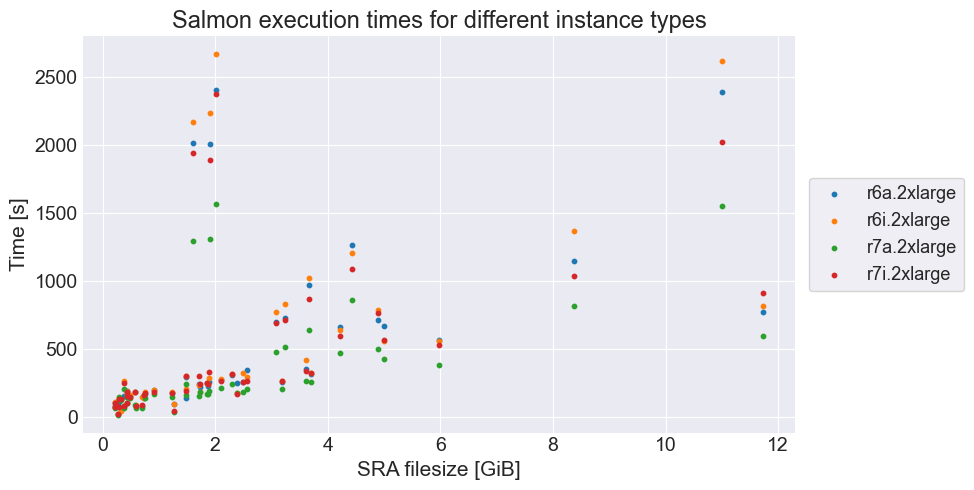

In [17]:
fig, ax = plt.subplots(ncols=1, figsize=(10, 5))

ax.scatter(df_c6a['SRR_filesize_bytes'] / 1024**3, df_c6a['salmon [s]'], label='r6a.2xlarge', s=10)
ax.scatter(df_c6i['SRR_filesize_bytes'] / 1024**3, df_c6i['salmon [s]'], label='r6i.2xlarge', s=10)
ax.scatter(df_c7a['SRR_filesize_bytes'] / 1024**3, df_c7a['salmon [s]'], label='r7a.2xlarge', s=10)
ax.scatter(df_c7i['SRR_filesize_bytes'] / 1024**3, df_c7i['salmon [s]'], label='r7i.2xlarge', s=10)

ax.set_xlabel('SRA filesize [GiB]', fontsize=15)
ax.set_ylabel('Time [s]', fontsize=15)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_title('Salmon execution times for different instance types', fontsize=17)

ax.legend(fontsize=13, bbox_to_anchor=(1.25, 0.5), frameon=True, loc='center right')
plt.tight_layout()
plt.savefig('plots/Salmon_instance_type_times.pdf', bbox_inches='tight')
plt.show()